In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("..\data\waze_dataset.csv")
df.head()

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\linda\AppData\Local\Temp\ipykernel_24276\4130905552.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv("..\data\waze_dataset.csv")


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [6]:
df.shape
df.info()
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  str    
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  str    
dtypes: float64(3), int64(8), str(2)
memory usage: 1.7 MB


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
count,14999.000000,14299,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,retained,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,iPhone
freq,NaN,11763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9672
mean,7499.000000,NaN,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879,NaN
std,4329.982679,NaN,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036,NaN
min,0.000000,NaN,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,NaN
25%,3749.500000,NaN,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,NaN
50%,7499.000000,NaN,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,NaN
75%,11248.500000,NaN,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,NaN


# Waze Device Type Hypothesis Test

## Project Overview

This project analyzes Waze user data to determine whether there is a statistically significant difference in the average number of drives between iPhone users and Android users.

The analysis is based on a two-sample hypothesis test.

## Business Question

Do drivers who use iPhone devices have the same average number of drives as drivers who use Android devices?

## Why This Matters

If driving behavior differs by device type, Waze leadership may need to consider device-specific product strategies, marketing decisions, or user experience improvements. However, if there is no significant difference, then device type may not be an important driver of ride activity.

In [13]:
map_dictionary = {
    "iPhone": 1,
    "Android": 2
}

df["device_type"] = df["device"].map(map_dictionary)

df[["device", "device_type"]].head()

,device,device_type
0,Android,2
1,iPhone,1
2,Android,2
3,iPhone,1
4,Android,2


In [14]:
df["device"].value_counts() 
df["device"].value_counts(normalize=True) * 100 

device
iPhone     64.484299
Android    35.515701
Name: proportion, dtype: float64

In [15]:
df.groupby("device")["drives"].mean()

device
Android    66.231838
iPhone     67.859078
Name: drives, dtype: float64

In [16]:
device_summary = df.groupby("device")["drives"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).reset_index()

device_summary

,device,count,mean,median,std,min,max
0,Android,5327,66.231838,47.0,64.240057,0,582
1,iPhone,9672,67.859078,48.0,66.814095,0,596


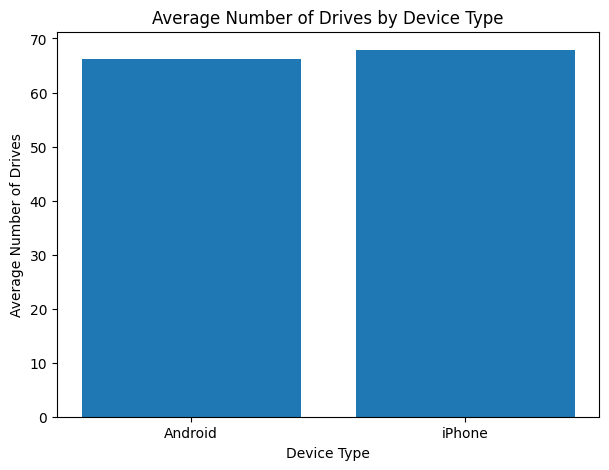

In [17]:
avg_drives = df.groupby("device")["drives"].mean().reset_index()

plt.figure(figsize=(7, 5))
plt.bar(avg_drives["device"], avg_drives["drives"])
plt.title("Average Number of Drives by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Number of Drives")
plt.show()

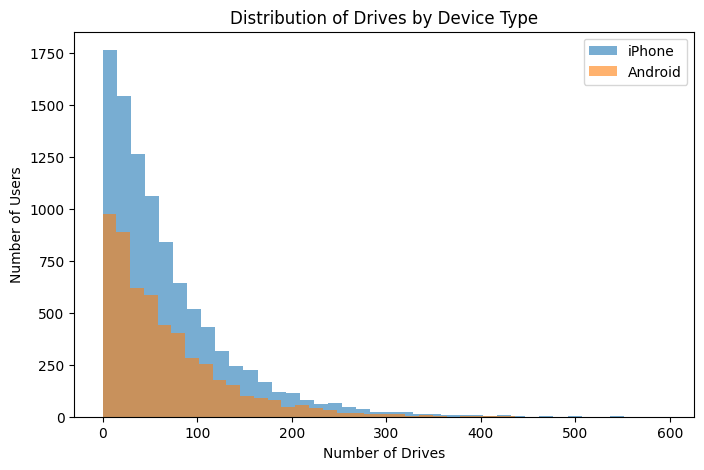

In [18]:
plt.figure(figsize=(8, 5))

iphone_drives = df[df["device"] == "iPhone"]["drives"]
android_drives = df[df["device"] == "Android"]["drives"]

plt.hist(iphone_drives, bins=40, alpha=0.6, label="iPhone")
plt.hist(android_drives, bins=40, alpha=0.6, label="Android")

plt.title("Distribution of Drives by Device Type")
plt.xlabel("Number of Drives")
plt.ylabel("Number of Users")
plt.legend()
plt.show()

## Research Question

Do drivers who open the Waze application using an iPhone have the same number of drives on average as drivers who use Android devices?

## Hypotheses

**Null Hypothesis H₀:**  
There is no difference in the average number of drives between iPhone users and Android users.

**Alternative Hypothesis H₁:**  
There is a difference in the average number of drives between iPhone users and Android users.

In [19]:
iphone = df[df["device_type"] == 1]["drives"]
android = df[df["device_type"] == 2]["drives"]

t_stat, p_value = stats.ttest_ind(
    a=iphone,
    b=android,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.463523206885235
P-value: 0.143351972680206


In [20]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average drives between iPhone and Android users.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that average drives differ between iPhone and Android users.")

Fail to reject the null hypothesis.
There is not enough evidence to conclude that average drives differ between iPhone and Android users.


## Interpretation

The p-value is greater than the chosen significance level of 0.05. Therefore, we fail to reject the null hypothesis.

This means there is not enough statistical evidence to conclude that iPhone users and Android users have different average numbers of drives.

Although the sample averages may look slightly different, the difference is not statistically significant.

## Business Recommendation

Since device type does not appear to have a statistically significant relationship with average number of drives, Waze should investigate other factors that may better explain user behavior and churn risk.

Recommended next steps include analyzing:

- User tenure
- Number of sessions
- Total kilometers driven
- Driving days
- Activity level
- Churn status
- User engagement patterns

These variables may provide stronger insight into what drives user retention or churn.

## Executive Summary

This project analyzed whether there is a statistically significant difference in the average number of drives between Waze users on iPhone and Android devices.

A two-sample t-test was conducted using the number of drives as the outcome variable and device type as the comparison group.

The test result showed that the p-value was greater than the 5% significance level. Therefore, we failed to reject the null hypothesis.

This means there is not enough evidence to conclude that iPhone users and Android users have different average numbers of drives.

From a business perspective, device type does not appear to be a major factor explaining driving activity. Waze leadership should explore other behavioral variables, such as sessions, driving days, kilometers driven, and churn status, to better understand user engagement and retention.